# Inspect a graph Scenario

Load a graph-mode scenario script and walk every inspection surface before
running the simulation.

**Graph-mode scenarios** carry `nodes: list[NodeInstance]` and
`edges: list[EdgeSpec]` instead of the legacy `stores` list. The `is_graph`
property is `True` when `nodes` is non-empty. Two new inspection views are
available: `Scenario.nodes_df()` and `Scenario.edges_df()`.

This notebook uses `scenarios/example_homogeneous.py` (no OpenAI key required).

See `notebooks/00-build-or-load-world.ipynb` for the quickstart 3-node chain,
and `notebooks/01-inspect-world.ipynb` for World artifact inspection.

In [1]:
%load_ext autoreload
%autoreload 2

import os
from pathlib import Path

while not (Path.cwd() / 'pyproject.toml').exists():
    os.chdir('..')

import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)

from src.sim.scenario import load_scenario_from_path
import matplotlib
%matplotlib inline


## Load a scenario

Point `SCENARIO_PATH` at any scenario script that exposes a top-level
`scenario` attribute. The homogeneous example uses a hand-authored catalog
and requires no LLM or API key.

In [2]:
SCENARIO_PATH = 'scenarios/example_homogeneous.py'
# SCENARIO_PATH = 'scenarios/llm_world_20.py'


scenario = load_scenario_from_path(SCENARIO_PATH)
print(f'Loaded scenario: {len(scenario.catalog)} catalog items, '
      f'{len(scenario.nodes)} node instances, '
      f'{len(scenario.edges)} edges, '
      f'{scenario.n_steps} steps')
print(f'is_graph: {scenario.is_graph}')

Loaded scenario: 5 catalog items, 33 node instances, 30 edges, 50 steps
is_graph: True


### Summary — top-level simulation parameters

One-row overview: step count, start date, world seed, and the size of the
catalog and node roster. Use this as a quick sanity check.

In [3]:
scenario.summary_df()

,n_steps,start_date,world_seed,n_products,n_nodes,n_DemandSinkNode,n_FactoryNode,n_IntermediateNode
0,50,2024-01-01,42,5,33,15,15,3


### Nodes — the graph actors

`scenario.nodes_df()` returns one row per `NodeInstance`. Columns include:
`node_id`, `node_type` (`FactoryNode` / `IntermediateNode` / `DemandSinkNode`),
`region`, `init_seed`, `level` (echelon level, 0 = factory), and type-specific
fields (`product_id` for sinks, `carried_products` for intermediates, etc.).

`policy_class` is populated from the live policy attached by the scenario
script — `None` when the scenario is loaded from a serialised JSON artifact
(policies are not serialised by design).

In [4]:
nodes_df = scenario.nodes_df()
nodes_df

,node_id,node_type,region,init_seed,policy_class
0,store0-shop,IntermediateNode,US,1001,OrderUpToPolicy
1,store0-factory-P0000,FactoryNode,US,1100,StaticFactoryPolicy
2,store0-factory-P0001,FactoryNode,US,1101,StaticFactoryPolicy
3,store0-factory-P0002,FactoryNode,US,1102,StaticFactoryPolicy
4,store0-factory-P0003,FactoryNode,US,1103,StaticFactoryPolicy
5,store0-factory-P0004,FactoryNode,US,1104,StaticFactoryPolicy
6,store0-sink-P0000,DemandSinkNode,US,1003,DefaultDemandSinkPolicy
7,store0-sink-P0001,DemandSinkNode,US,1004,DefaultDemandSinkPolicy
8,store0-sink-P0002,DemandSinkNode,US,1005,DefaultDemandSinkPolicy
9,store0-sink-P0003,DemandSinkNode,US,1006,DefaultDemandSinkPolicy


In [5]:
# Count by node type
nodes_df['node_type'].value_counts()

node_type
FactoryNode         15
DemandSinkNode      15
IntermediateNode     3
Name: count, dtype: int64

In [6]:
# Policy class per node type — confirm all shops share one policy class
nodes_df.groupby('node_type')['policy_class'].value_counts()

node_type         policy_class           
DemandSinkNode    DefaultDemandSinkPolicy    15
FactoryNode       StaticFactoryPolicy        15
IntermediateNode  OrderUpToPolicy             3
Name: count, dtype: int64

### Edges — supply links between nodes

`scenario.edges_df()` returns one row per `EdgeSpec`. Columns: `supplier_id`,
`buyer_id`, `default_lead_time`, `per_product_lead_time` (dict of per-product
overrides, or `None` when the default applies to all products).

In [7]:
edges_df = scenario.edges_df()
edges_df

,supplier_id,buyer_id,default_lead_time
0,store0-factory-P0000,store0-shop,2
1,store0-factory-P0001,store0-shop,2
2,store0-factory-P0002,store0-shop,2
3,store0-factory-P0003,store0-shop,2
4,store0-factory-P0004,store0-shop,2
5,store0-shop,store0-sink-P0000,1
6,store0-shop,store0-sink-P0001,1
7,store0-shop,store0-sink-P0002,1
8,store0-shop,store0-sink-P0003,1
9,store0-shop,store0-sink-P0004,1


In [8]:
# Lead time distribution
edges_df['default_lead_time'].value_counts().rename('edge_count').to_frame()

,edge_count
default_lead_time,
2,15
1,15


### Catalog — items for sale

One row per SKU. `freshness_alpha` and `freshness_decay` govern the hype-curve
multiplier inside `DemandSinkNode.demand_target`.

In [9]:
scenario.catalog_df()

,product_id,name,category,base_price,unit_cost,margin,seasonality,freshness_alpha,freshness_decay,init_stage,stage_change_probs,init_stock_share,related_products
0,P0000,Widget A,Widgets,20.0,12.0,8.0,all_season,None,None,None,None,None,[]
1,P0001,Widget B,Widgets,30.0,18.0,12.0,all_season,None,None,None,None,None,"[(Widget A, 0.5)]"
2,P0002,Widget C,Widgets,15.0,8.0,7.0,all_season,None,None,None,None,None,[]
3,P0003,Gadget A,Gadgets,25.0,15.0,10.0,all_season,None,None,None,None,None,[]
4,P0004,Gadget B,Gadgets,18.0,10.0,8.0,all_season,None,None,None,None,None,[]


### Market — demand and seasonality parameters

In [10]:
scenario.market_df().T

,0
cycle_len,365
cycle_amp,0.3
init_demand,1.0
init_supply,1.0
peak_factor,1.2
off_factor,0.7
season_months,"{'all_season': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10,..."
regions,[US]
correlation,0.7
trend_update_interval,20


### Disruption — supply-chain shock parameters

Governs random disruption events: `event_prob` is the per-step probability,
`types` lists the event categories, `severity` and `duration` are
`Distribution` objects sampled at event time.

In [11]:
scenario.disruption_df()

,event_prob,types,regions,severity,duration
0,0.05,"[natural_disaster, economic_crisis]",[US],Constant(value=0.01),Constant(value=3)


### Lifecycle — product stage defaults

In [12]:
scenario.lifecycle_df()

,stages,init_stage,default_stage_change_probs,default_freshness_alpha,default_freshness_decay,default_init_stock_share
0,"[introduction, growth, maturity, decline, dead]",maturity,"{'introduction': 0.0, 'growth': 0.0, 'maturity...",0.0,1.0,1.0


## Visualise the graph topology

Build a simple adjacency list from `edges_df` and print the factory→shop→sink chains.

In [13]:
from collections import defaultdict

children: dict[str, list[str]] = defaultdict(list)
for _, row in edges_df.iterrows():
    children[row['supplier_id']].append(row['buyer_id'])

# Find roots (nodes that never appear as a buyer)
all_buyers = set(edges_df['buyer_id'])
roots = [ni.node.id for ni in scenario.nodes if ni.node.id not in all_buyers]

def print_tree(node_id: str, prefix: str = "", last: bool = True):
    connector = '└── ' if last else '├── '
    print(prefix + connector + node_id)
    child_ids = children.get(node_id, [])
    for i, child in enumerate(child_ids):
        new_prefix = prefix + ('    ' if last else '│   ')
        print_tree(child, new_prefix, i == len(child_ids) - 1)

for root in sorted(roots):
    print_tree(root)

└── store0-factory-P0000
    └── store0-shop
        ├── store0-sink-P0000
        ├── store0-sink-P0001
        ├── store0-sink-P0002
        ├── store0-sink-P0003
        └── store0-sink-P0004
└── store0-factory-P0001
    └── store0-shop
        ├── store0-sink-P0000
        ├── store0-sink-P0001
        ├── store0-sink-P0002
        ├── store0-sink-P0003
        └── store0-sink-P0004
└── store0-factory-P0002
    └── store0-shop
        ├── store0-sink-P0000
        ├── store0-sink-P0001
        ├── store0-sink-P0002
        ├── store0-sink-P0003
        └── store0-sink-P0004
└── store0-factory-P0003
    └── store0-shop
        ├── store0-sink-P0000
        ├── store0-sink-P0001
        ├── store0-sink-P0002
        ├── store0-sink-P0003
        └── store0-sink-P0004
└── store0-factory-P0004
    └── store0-shop
        ├── store0-sink-P0000
        ├── store0-sink-P0001
        ├── store0-sink-P0002
        ├── store0-sink-P0003
        └── store0-sink-P0004
└── store1-factory-P0000


## Run the scenario

In [14]:
from src.sim.runner import Runner

run_log = Runner(scenario).run()
print(f'Run log: {run_log["n_steps"]} steps, {len(run_log["ticks"])} tick records')
print(f'Global keys: {list(run_log["global"].keys())}')

Run log: 50 steps, 50 tick records
Global keys: ['time', 'market_supply', 'market_demand', 'products', 'events']


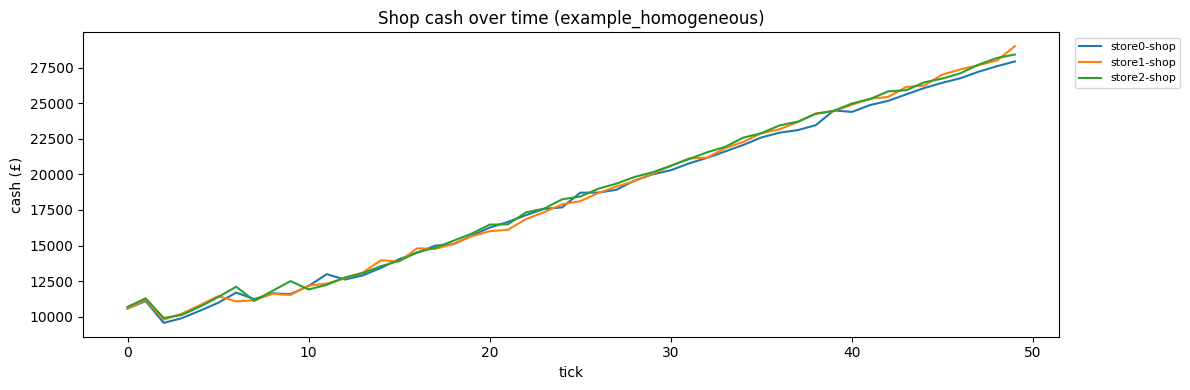

In [15]:
import matplotlib.pyplot as plt
from src.sim.node import IntermediateNode

shop_ids = sorted(ni.node.id for ni in scenario.nodes if isinstance(ni.node, IntermediateNode))

cash_by_shop = {sid: [t['node_cash'].get(sid, 0.0) for t in run_log['ticks']] for sid in shop_ids}

fig, ax = plt.subplots(figsize=(12, 4))
for sid, vals in cash_by_shop.items():
    ax.plot(vals, label=sid)
ax.set_title('Shop cash over time (example_homogeneous)')
ax.set_xlabel('tick')
ax.set_ylabel('cash (£)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

## (Optional) Historical-run audit via `Scenario.from_json`

After running a simulation, the exporter serialises the scenario to
`data/<run>/config/scenario.json`. Load it back with `Scenario.from_json` to
inspect the exact graph topology used in a past run.

**Note:** `policy_class` is `None` in `nodes_df()` of a deserialised scenario
— this is by design; policies are not serialised.

In [16]:
from src.sim.scenario import Scenario

SCENARIO_JSON_PATH = Path('data/example_homogeneous/config/scenario.json')

if SCENARIO_JSON_PATH.exists():
    scenario_from_run = Scenario.from_json(SCENARIO_JSON_PATH.read_text())
    print('Loaded from historical run artifact')
    print(f'is_graph: {scenario_from_run.is_graph}')
    print(f'nodes: {len(scenario_from_run.nodes)}, edges: {len(scenario_from_run.edges)}')
    display(scenario_from_run.nodes_df())
    print('\nNote: policy_class is None by design — policies are not serialised.')
else:
    print(f'Artifact not found: {SCENARIO_JSON_PATH}')
    print('Run `uv run python main.py scenarios/example_homogeneous.py` to generate it.')

Loaded from historical run artifact
is_graph: True
nodes: 33, edges: 30


,node_id,node_type,region,init_seed,policy_class
0,store0-shop,IntermediateNode,US,1001,None
1,store0-factory-P0000,FactoryNode,US,1100,None
2,store0-factory-P0001,FactoryNode,US,1101,None
3,store0-factory-P0002,FactoryNode,US,1102,None
4,store0-factory-P0003,FactoryNode,US,1103,None
5,store0-factory-P0004,FactoryNode,US,1104,None
6,store0-sink-P0000,DemandSinkNode,US,1003,None
7,store0-sink-P0001,DemandSinkNode,US,1004,None
8,store0-sink-P0002,DemandSinkNode,US,1005,None
9,store0-sink-P0003,DemandSinkNode,US,1006,None



Note: policy_class is None by design — policies are not serialised.
